## Process similar claims and subsample for contradiction analysis

In [1]:
import pandas as pd

court_cases = pd.read_csv('../clean_data_with_details.csv')
print("Loaded court cases:", court_cases.shape)

similar_claims = pd.read_csv('../results/similarity_report.csv') # All claims similarities
print("Loaded similar claims:", similar_claims.shape)

Loaded court cases: (3303, 18)
Loaded similar claims: (54909960, 9)


<Axes: title={'center': 'Distribution of Similarity Scores between Case Claims'}, ylabel='Frequency'>

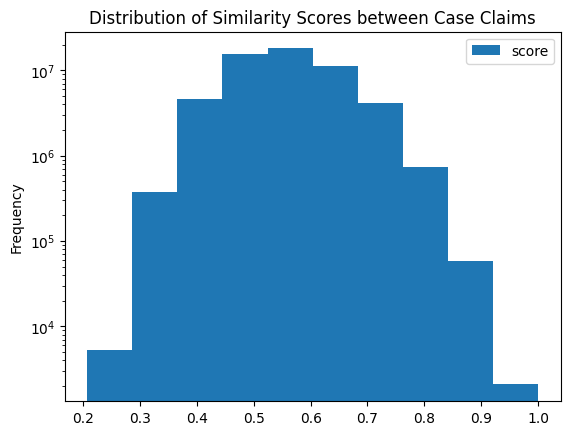

In [ ]:
similar_claims.plot.hist(column='score', bins=10, logy=True, title='Distribution of Similarity Scores between Case Claims')

In [ ]:
# Get the similarity of ALL claim pairs [done]
# Uniformly select 10K claim pairs based on similarity
# Look at where contradicting claims appear in distribution
# Pray its not uniform

In [31]:
# Sample 10K claim pairs uniformly across similarity scores
subsample_data = pd.concat([
    # similar_claims[similar_claims['score'] <= 0.1].sample(n=1000, random_state=42), # zero in this bin
    # similar_claims[(similar_claims['score'] > 0.1) & (similar_claims['score'] <= 0.2)].sample(n=1000, random_state=42), # zero in this bin too
    similar_claims[(similar_claims['score'] > 0.2) & (similar_claims['score'] <= 0.3) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.3) & (similar_claims['score'] <= 0.4) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.4) & (similar_claims['score'] <= 0.5) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.5) & (similar_claims['score'] <= 0.6) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.6) & (similar_claims['score'] <= 0.7) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.7) & (similar_claims['score'] <= 0.8) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.8) & (similar_claims['score'] <= 0.9) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.9) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
])

In [36]:
subsample_data_with_facts = subsample_data.merge(
    court_cases[['docket', 'name', 'facts', 'api_question', 'api_conclusion']],
    left_on=['docket1', 'name1'],
    right_on=['docket', 'name'],
    how='left'
)

subsample_data_with_facts.rename(
    columns={
        'facts': 'facts1',
        'api_question': 'api_question1',
        'api_conclusion': 'api_conclusion1'
    },
    inplace=True
)
subsample_data_with_facts.drop(columns=['docket', 'name'], inplace=True)

subsample_data_with_facts = subsample_data_with_facts.merge(
    court_cases[['docket', 'name', 'facts', 'api_question', 'api_conclusion']],
    left_on=['docket2', 'name2'],
    right_on=['docket', 'name'],
    how='left'
)

subsample_data_with_facts.rename(
    columns={
        'facts': 'facts2',
        'api_question': 'api_question2',
        'api_conclusion': 'api_conclusion2'
    },
    inplace=True
)
subsample_data_with_facts.drop(columns=['docket', 'name'], inplace=True)

subsample_data_with_facts = subsample_data_with_facts[['claim1', 'docket1', 'name1', 'facts1', 'api_question1', 'api_conclusion1', 'claim2', 'docket2', 'name2', 'facts2', 'api_question2', 'api_conclusion2', 'score']]

<Axes: title={'center': 'Distribution of Similarity Scores in Subsample'}, ylabel='Frequency'>

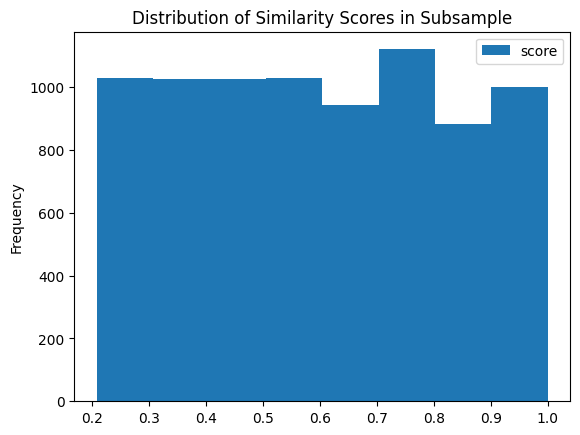

In [39]:
subsample_data_with_facts.plot.hist(column='score', bins=8, title='Distribution of Similarity Scores in Subsample')

In [44]:
PROMPT_TEMPLATE = """You are a legal expert. You will be given two claims from different court cases along with their associated facts, legal questions, and conclusions. 
Your task is to determine whether the two claims either contradict, overlap, or have no relation to each other based on the provided information. 

## Output Format:
Return a JSON object in the following format:
```json
{{
    "explanation": "...",
    "contradiction": "Contradict" | "Overlap" | "Irrelevant"
    ...
}}
```

## {name1}
Facts: {facts1}
Legal Question: {api_question1}
Conclusion: {api_conclusion1}

## {name2}
Facts: {facts2}
Legal Question: {api_question2}
Conclusion: {api_conclusion2}

Claim 1: {claim1}
Claim 2: {claim2}
"""

subsample_data_with_facts['prompt'] = subsample_data_with_facts.apply(lambda row: PROMPT_TEMPLATE.format(
    **row
), axis=1)

In [46]:
subsample_data_with_facts.to_json('../results/subsampled_claims_for_contradiction_analysis.jsonl', orient='records', lines=True)

## Prompt LLM

...

## Analyze LLM responses